# Scenario analysis - creating a line plot

The ability to examine relationships between system parameters and system variables is a powerful capability offered by the Dispatch API. This notebook outlines a workflow that can be used to perform ex-post scenario analyses using historical case file data. While the following sections examine how changes to demand forecasts would likely influence prices in a given region, the same principles can be applied to examine other relationships.

## Imports

In [1]:
import requests
import xmltodict
import matplotlib.pyplot as plt
from jsonpath_ng.ext import parse

# Base URL endpoint for the Dispatch API
base_url = 'http://localhost:8000/'

Matplotlib is building the font cache; this may take a moment.


## Load case file
We need some data to work with, so let's proceed by loading a case file.

In [2]:
def convert_casefile(path_to_file):
    """Load a historical NEMDE case file and convert it to a dict"""

    # Read case file contents
    with open(path_to_file, 'r') as f:
        casefile = f.read()

    # Force these nodes to always return lists
    force_list = ('Trade', 'TradeTypePriceStructure',)

    return xmltodict.parse(casefile, force_list=force_list)


def load_casefile(case_id):
    """Load case file"""
    
    # Load case file and convert to JSON
    casefile = convert_casefile(f'../../data/NEMSPDOutputs_{case_id}00.loaded')
   
    return casefile

# Load case file
case_id = '20210401001'
casefile = load_casefile(case_id=case_id)

## Approach
It is always a good idea to separate data from logic. Let's treat the case file that we saved to disk as our canonical 'source of truth', with this 'base' case file loaded before performing each update. As this case file will never be overwritten we can be sure we're using the same data before making updates, thus reducing the possibility of introducing unintended changes.

The following function reads the base case file from disk then updates the Demand Forecast (`@DF`) parameter for South Australia. This allows us to investigate how prices respond to changes in anticipated demand.

In [3]:
def update_region_demand_forecast(case_id, region_id, value):
    """Load case file and update demand forecast for a given region"""
    
    # Load base case file
    casefile = load_casefile(case_id=case_id)

    # Construct expression
    expression = (f"NEMSPDCaseFile \
                  .NemSpdInputs \
                  .PeriodCollection \
                  .Period \
                  .RegionPeriodCollection \
                  .RegionPeriod[?(@RegionID=='{region_id}')] \
                  .@DF")

    # Construct JSON path expression
    jsonpath_expr = parse(expression)

    # Update value
    _ = jsonpath_expr.update(casefile, value)
    
    return casefile

## Run scenarios
A modified case file is submitted to the `/solve` endpoint for each `@DF` value under investigation. As the API returns the solution in its response, each solution can be stored alongside the `@DF` value used to obtain it.

In [4]:
def solve_casefile(base_url, casefile):
    """Submit a case file to the Dispatch API and return the solution"""

    url = base_url + 'solve'
    response = requests.post(url=url, json=casefile)
    response.raise_for_status()

    return response.json()


def run_scenarios(base_url, case_id, region_id, values):
    """Solve a modified case file for each demand forecast value"""

    scenarios = []
    for i in values:
        # Update the base case file and solve the model
        casefile = update_region_demand_forecast(case_id=case_id, region_id=region_id, value=i)
        solution = solve_casefile(base_url=base_url, casefile=casefile)

        # Store the solution alongside the value of the parameter used in the analysis
        scenarios.append({'demand_forecast': i, 'solution': solution})

    return scenarios

# Demand forecast parameters
values = [-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50]
scenarios = run_scenarios(base_url=base_url, case_id=case_id, region_id='SA1', values=values)

## Results
The following function searches a solution dictionary for the energy price corresponding to a given region. This will allow us to examine how the energy price changes as the `@DF` parameter is augmented.

In [5]:
def get_region_energy_price(solution, region_id):
    """Extract energy price from solution dictionary"""
    
    expression = (f"RegionSolution[?(@RegionID='{region_id}')] \
                  .@EnergyPrice")

    jsonpath_expr = parse(expression)   
    values = [match.value for match in jsonpath_expr.find(solution)]
    
    # Only one value should be returned
    if len(values) != 1:
        msg = f"Should only return 1 value, encountered: {len(values)} {region_id}"
        raise Exception(msg)

    return values[0]

Demand Forecast parameters can now be mapped to price outcomes.

In [6]:
def map_parameters_to_prices(scenarios, region_id):
    """Map demand forecast parameters to energy prices"""

    # Combine into list of tuples [(demand_forecast, price), ...]
    values = [(scenario.get('demand_forecast'),
               get_region_energy_price(solution=scenario.get('solution'), region_id=region_id))
              for scenario in scenarios]

    return sorted(values, key=lambda x: x[0])


# Price results
price_results = map_parameters_to_prices(scenarios=scenarios, region_id='SA1')

The results can be plotted to reveal the relationship between `@DF` values and energy prices in South Australia.

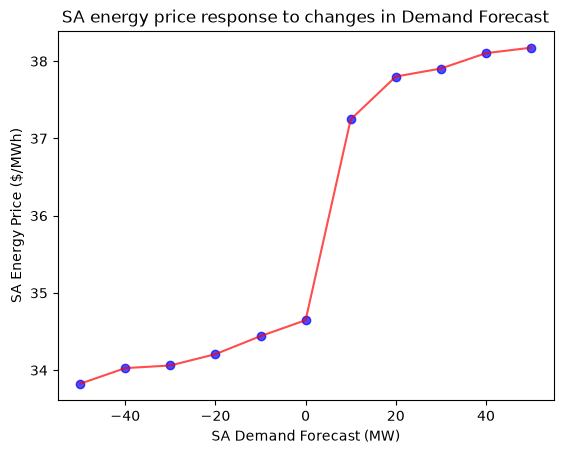

In [7]:
# Unzip for plotting
x, y = zip(*price_results)

# Plotting results
fig, ax = plt.subplots()
ax.plot(x, y,'o', alpha=0.7, color='b')
ax.plot(x, y,'-', alpha=0.7, color='r')
ax.set_title('SA energy price response to changes in Demand Forecast')
ax.set_xlabel('SA Demand Forecast (MW)')
ax.set_ylabel('SA Energy Price ($/MWh)')
plt.show()

The plot illustrates the ranges of `@DF` values over which the energy price in South Australia is relatively insensitive to changes in demand, and also the point at which prices step up sharply. This type of analysis can help identify how sensitive prices are to changes in demand.

## Summary
This notebook outlines a workflow that can be used to perform sensitivity analyses. Relationships between other parameters and variables can be readily investigated, making the Dispatch API a flexible tool that can facilitate a number of different studies. For instance, one may wish to know how prices or other system variables are impacted by a contingency such as sudden reduction in interconnector power flow limits, or the tripping of a generator.

While this tutorial has used historical data to perform an ex-post sensitivity analysis, the Dispatch API can also be used with customised case files. This lends the Dispatch API to a number of forecasting applications - user supplied forecasts for case file parameters could allow sensitivities to be computed in real time.